# RL Deblur cho biển số xe (PixelRL + A2C + Reward Map Convolution)

Notebook này tự chứa toàn bộ pipeline RL khử mờ ảnh biển số xe, train trên GPU Colab.

**Cần chuẩn bị trước khi chạy** (trên máy local, trong thư mục repo `parseq_official_pipeline`):

```bash
zip -r parseq_rl_deblur_data.zip color_filtered parseq preprocessing_best_config outputs/refinement_finetune
```

Rồi upload file `parseq_rl_deblur_data.zip` lên Google Drive (vd thư mục gốc `My Drive/`).
File này chứa: ảnh biển số sạch (`color_filtered/`), source PARSeq (`parseq/`), code tiền xử lý
(`preprocessing_best_config/`), và checkpoint PARSeq đã fine-tune (`outputs/refinement_finetune/best_official_parseq_anpr.pt`)
dùng làm 'giám khảo' OCR để chấm reward/đánh giá.

**Runtime**: Menu `Runtime > Change runtime type > GPU (T4)` trước khi chạy.

## 1. Mount Google Drive + cấu hình đường dẫn

In [28]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Sua duong dan nay cho khop voi noi ban upload file zip tren Drive
# DRIVE_ZIP_PATH = '/content/drive/MyDrive/parseq_rl_deblur_data.zip'
# PROJECT_DIR = '/content/project'

In [29]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

CUDA available: True
Device name: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Giải nén dữ liệu + cài dependency

In [30]:
# import os
# os.makedirs(PROJECT_DIR, exist_ok=True)
# !unzip -q -o "{DRIVE_ZIP_PATH}" -d {PROJECT_DIR}
# !ls {PROJECT_DIR}

In [31]:
# %pip install -q opencv-python-headless scikit-image pandas pillow tqdm timm pytorch-lightning lmdb nltk torchvision

## 3. Ghi package `rl_deblur` vào project

Các cell dưới dùng `%%writefile` để tạo lại đúng source code đã được viết và debug kỹ ở máy local
(bao gồm toàn bộ quá trình tìm và sửa lỗi sụp đổ training). Không cần chỉnh sửa gì thêm.

In [32]:
# Local run
PROJECT_DIR = r"D:\NEO\rl_pipeline\parseq_rl_deblur_data"

In [33]:
import os
os.chdir(PROJECT_DIR)
os.makedirs('rl_deblur', exist_ok=True)
open('rl_deblur/__init__.py', 'w').close()
print('cwd:', os.getcwd())

cwd: D:\NEO\rl_pipeline\parseq_rl_deblur_data


In [34]:
%%writefile rl_deblur/env.py
"""PixelRL-style environment: per-pixel discrete action set + dense reward.

Following "Fully Convolutional Network with Multi-Step Reinforcement Learning
for Image Processing" (Furuta et al.), every pixel is treated as an agent that
picks one operation from a shared toolbox each step. Because the policy
network is fully convolutional, all pixels share the same weights; we simply
compute every candidate operation over the *whole* image and then, per pixel,
select the value produced by whichever action that pixel chose.
"""

from __future__ import annotations

import cv2
import numpy as np

ACTIONS = [
    "keep",
    "pixel+1",
    "pixel-1",
    "pixel+3",
    "pixel-3",
    "gaussian_smooth",
    "bilateral_filter",
    "unsharp_mild",
    "unsharp_strong",
]
NUM_ACTIONS = len(ACTIONS)
PIXEL_DELTA = {1: 1.0, 2: -1.0, 3: 3.0, 4: -3.0}


def _unsharp(img_u8: np.ndarray, amount: float, sigma: float = 1.0) -> np.ndarray:
    blur = cv2.GaussianBlur(img_u8, (0, 0), sigma)
    sharp = img_u8.astype(np.float32) + amount * (img_u8.astype(np.float32) - blur.astype(np.float32))
    return np.clip(sharp, 0, 255).astype(np.uint8)


def compute_candidates(state: np.ndarray) -> np.ndarray:
    """state: (B, H, W) float32 in [0, 255]. Returns (B, NUM_ACTIONS, H, W) float32."""
    batch = state.shape[0]
    h, w = state.shape[1], state.shape[2]
    out = np.empty((batch, NUM_ACTIONS, h, w), dtype=np.float32)
    for b in range(batch):
        img_f = state[b]
        img_u8 = np.clip(img_f, 0, 255).astype(np.uint8)
        out[b, 0] = img_f
        for action_id, delta in PIXEL_DELTA.items():
            out[b, action_id] = np.clip(img_f + delta, 0, 255)
        out[b, 5] = cv2.GaussianBlur(img_u8, (3, 3), 0.5).astype(np.float32)
        out[b, 6] = cv2.bilateralFilter(img_u8, d=5, sigmaColor=25, sigmaSpace=5).astype(np.float32)
        out[b, 7] = _unsharp(img_u8, amount=0.5).astype(np.float32)
        out[b, 8] = _unsharp(img_u8, amount=1.5).astype(np.float32)
    return out


def step(state: np.ndarray, action_map: np.ndarray, clean: np.ndarray):
    """Apply per-pixel actions and compute the dense restoration reward.

    state: (B, H, W) float32 in [0, 255], current (possibly partially restored) image.
    action_map: (B, H, W) int64, action index chosen per pixel.
    clean: (B, H, W) float32 in [0, 255], ground-truth sharp image.

    Returns (next_state, reward) both (B, H, W) float32.
    """
    candidates = compute_candidates(state)
    next_state = np.take_along_axis(candidates, action_map[:, None, :, :], axis=1).squeeze(1)
    se_before = (state - clean) ** 2
    se_after = (next_state - clean) ** 2
    reward = (se_before - se_after) / (255.0 ** 2)
    return next_state, reward


Overwriting rl_deblur/env.py


In [35]:
%%writefile rl_deblur/model.py
"""Fully convolutional actor-critic shared by every pixel (PixelRL-style).

7 conv layers with a dilation schedule (1,2,3,4,3,2,1) to grow the receptive
field without losing spatial resolution, then two 1-conv heads: a policy head
(per-pixel action logits) and a value head (per-pixel state value).

Also implements Reward Map Convolution (RMC) from the original paper -- the
technique the paper reports as its main performance driver. A learnable
spatial kernel lets each pixel's return bootstrap off its *neighbors'*
predicted values, not just its own, which propagates information faster
across flat/uniform regions of the plate (e.g. background) where a single
pixel's own reward signal is weak or noisy.
"""

from __future__ import annotations

import torch
import torch.nn.functional as F
from torch import nn

from rl_deblur.env import NUM_ACTIONS

DILATIONS = [1, 2, 3, 4, 3, 2, 1]


class RewardMapConv(nn.Module):
    """Learnable local-averaging kernel w used to convolve future value/reward maps.

    Weights are softmax-normalized so they always sum to 1 (a proper spatial
    weighted average, matching the w in Eq. 12-13 of the paper). Initialized
    near-identity (all weight on the center tap) so early training behaves
    like plain per-pixel A2C and gradually learns to spread credit spatially.
    """

    def __init__(self, kernel_size: int = 9):
        super().__init__()
        assert kernel_size % 2 == 1
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2
        init = torch.zeros(kernel_size * kernel_size)
        center = (kernel_size * kernel_size) // 2
        init[center] = 8.0  # softmax(logits) -> ~near one-hot at center initially
        self.logits = nn.Parameter(init)

    def kernel(self) -> torch.Tensor:
        w = torch.softmax(self.logits, dim=0).view(1, 1, self.kernel_size, self.kernel_size)
        return w

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, H, W) -> (B, H, W), same-size convolution per image."""
        w = self.kernel().to(dtype=x.dtype, device=x.device)
        out = F.conv2d(x.unsqueeze(1), w, padding=self.padding)
        return out.squeeze(1)


def _make_trunk(channels: int) -> nn.Sequential:
    layers = []
    in_ch = 1
    for dilation in DILATIONS:
        layers.append(nn.Conv2d(in_ch, channels, kernel_size=3, padding=dilation, dilation=dilation))
        layers.append(nn.ReLU(inplace=True))
        in_ch = channels
    return nn.Sequential(*layers)


class FCNActorCritic(nn.Module):
    """Separate policy and value trunks (rather than one shared trunk).

    A shared-trunk design was tried first (as in most actor-critic setups)
    but proved unstable here: gradients from the value regression flowed
    back through the shared features and measurably dragged the policy's
    output distribution away from its initial "do nothing" bias within a
    handful of epochs, causing a sudden collapse in restoration quality that
    was reproducible regardless of entropy coefficient or bootstrap target.
    Fully separate trunks remove that interference pathway at a modest
    (roughly 2x trunk) compute cost, which is negligible at this image size.
    """

    def __init__(self, channels: int = 64, num_actions: int = NUM_ACTIONS, rmc_kernel_size: int = 9):
        super().__init__()
        self.policy_trunk = _make_trunk(channels)
        self.value_trunk = _make_trunk(channels)
        self.policy_head = nn.Conv2d(channels, num_actions, kernel_size=3, padding=1)
        self.value_head = nn.Conv2d(channels, 1, kernel_size=3, padding=1)
        self.rmc = RewardMapConv(kernel_size=rmc_kernel_size)

        # Plain default (PyTorch Kaiming) init for both heads. Two "safety"
        # inits were tried and both backfired: (1) zeroing policy_head and
        # biasing it toward action 0 ("keep") was meant to avoid a bad
        # untrained policy, but Adam normalizes gradients by their running
        # RMS, so every weight element -- all starting from *exactly* the
        # same value -- drifts at a similar ~lr-sized step regardless of the
        # (tiny) raw loss, and once that shared drift crossed the fixed bias
        # margin, many pixels flipped their action simultaneously, causing a
        # sudden collapse reproducible across many unrelated hyperparameter
        # changes; (2) shrinking value_head's init didn't fix it either.
        # Plain small-random default init avoids the knife-edge/lockstep
        # dynamics of a special init entirely and is what the first,
        # empirically-stable version of this pipeline used.
        nn.init.uniform_(self.value_head.weight, -1e-3, 1e-3)
        nn.init.zeros_(self.value_head.bias)

    def forward(self, x: torch.Tensor):
        """x: (B, 1, H, W) in [0, 1]. Returns (policy_logits (B,A,H,W), value (B,H,W))."""
        logits = self.policy_head(self.policy_trunk(x))
        value = self.value_head(self.value_trunk(x)).squeeze(1)
        return logits, value


Overwriting rl_deblur/model.py


In [36]:
%%writefile rl_deblur/ocr_utils.py
"""Shared helpers to load the fine-tuned PARSeq checkpoint and run OCR.

Used both as an *evaluation* metric (evaluate.py) and, optionally, as part of
the *training* reward (train.py) -- to reward-shape the RL policy toward
plates that PARSeq actually reads correctly, not just toward low pixel error.
"""

from __future__ import annotations

import sys
from pathlib import Path

import torch
from PIL import Image

REPO_ROOT = Path(__file__).resolve().parents[1]
if str(REPO_ROOT / "parseq") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "parseq"))
if str(REPO_ROOT / "preprocessing_best_config") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "preprocessing_best_config"))

from strhub.data.module import SceneTextDataModule  # noqa: E402
from strhub.models.utils import create_model  # noqa: E402

DEFAULT_OCR_CKPT = REPO_ROOT / "outputs" / "refinement_finetune" / "best_official_parseq_anpr.pt"
ANPR_CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"


def normalize_plate_text(text: object) -> str:
    return "".join(ch for ch in str(text).upper() if ch in ANPR_CHARSET)


def edit_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        cur = [i]
        for j, cb in enumerate(b, start=1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def load_ocr_model(device, checkpoint_path: str | Path = DEFAULT_OCR_CKPT):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg = ckpt["config"]
    model = create_model(
        cfg["experiment"], pretrained=False, decode_ar=cfg["decode_ar"],
        refine_iters=cfg["refine_iters"], charset_test=cfg["charset_test"],
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model._device = device
    model.to(device).eval()
    img_size = tuple(cfg["img_size"])
    transform = SceneTextDataModule.get_transform(img_size, augment=False)
    return model, transform


@torch.no_grad()
def ocr_predict(model, transform, gray_u8_batch, device) -> list[str]:
    preds, _ = ocr_predict_with_confidence(model, transform, gray_u8_batch, device)
    return preds


@torch.no_grad()
def ocr_predict_with_confidence(model, transform, gray_u8_batch, device) -> tuple[list[str], list[float]]:
    """Returns (normalized predictions, log-confidence = sum of log token-probs)."""
    tensors = []
    for gray in gray_u8_batch:
        rgb = Image.fromarray(gray).convert("RGB")
        tensors.append(transform(rgb))
    batch = torch.stack(tensors).to(device)
    logits = model(batch)
    probs = logits.softmax(-1)
    preds, token_probs = model.tokenizer.decode(probs)
    preds = [normalize_plate_text(p) for p in preds]
    log_confidences = [float(torch.log(tp.clamp_min(1e-8)).sum().item()) for tp in token_probs]
    return preds, log_confidences


Overwriting rl_deblur/ocr_utils.py


In [37]:
%%writefile rl_deblur/make_dataset.py
"""Synthesize a paired (blurred, clean) plate-crop dataset for RL-based deblurring.

The project has no real blurry plate images, so we start from the clean plate
crops under ``color_filtered/`` and synthetically degrade them with Gaussian /
motion / defocus blur. Ground truth (the original clean pixels) is kept so the
RL environment can compute a dense per-pixel reward.
"""

from __future__ import annotations

import argparse
import random
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

REPO_ROOT = Path(__file__).resolve().parents[1]
SOURCE_DIRS = ["color_filtered/blue", "color_filtered/other", "color_filtered/yellow"]
DEFAULT_OUTPUT_DIR = REPO_ROOT / "outputs" / "rl_deblur" / "dataset"
CANVAS_SIZE = (128, 32)  # (width, height), matches PARSeq img_size=(32,128) convention


@dataclass
class BlurSpec:
    kind: str
    strength: float


def list_clean_samples() -> list[tuple[Path, str]]:
    samples = []
    for rel in SOURCE_DIRS:
        folder = REPO_ROOT / rel
        labels_path = folder / "labels.txt"
        if not labels_path.exists():
            continue
        for line in labels_path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line:
                continue
            fname, label = line.split("\t")
            img_path = folder / fname
            if img_path.exists():
                samples.append((img_path, label))
    return samples


def random_blur_spec(rng: random.Random) -> BlurSpec:
    """Mild, recoverable degradation levels.

    The original ranges (gaussian sigma up to 2.5, defocus sigma up to 4.5,
    motion length up to 13) destroy enough high-frequency text detail on a
    32x128 crop that no restoration policy -- RL or otherwise -- can recover
    the character shapes. These lighter ranges keep stroke edges partially
    intact so the reward signal (pixel error reduction) has something to
    learn from.
    """
    kind = rng.choice(["gaussian", "motion", "defocus"])
    if kind == "gaussian":
        strength = rng.uniform(0.8, 1.8)
    elif kind == "motion":
        strength = rng.uniform(4, 9)
    else:  # defocus (larger gaussian to emulate out-of-focus blur)
        strength = rng.uniform(1.5, 3.0)
    return BlurSpec(kind=kind, strength=strength)


def apply_blur(gray: np.ndarray, spec: BlurSpec) -> np.ndarray:
    if spec.kind == "gaussian":
        ksize = int(spec.strength * 3) | 1  # force odd
        return cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=spec.strength)
    if spec.kind == "defocus":
        ksize = int(spec.strength * 3) | 1
        return cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=spec.strength)
    if spec.kind == "motion":
        length = max(int(spec.strength), 3)
        angle = random.uniform(0, 180)
        kernel = np.zeros((length, length), dtype=np.float32)
        kernel[length // 2, :] = 1.0
        rot_mat = cv2.getRotationMatrix2D((length / 2, length / 2), angle, 1.0)
        kernel = cv2.warpAffine(kernel, rot_mat, (length, length))
        kernel /= max(kernel.sum(), 1e-6)
        return cv2.filter2D(gray, -1, kernel)
    raise ValueError(spec.kind)


def to_canvas_gray(image: Image.Image) -> np.ndarray:
    resized = image.convert("L").resize(CANVAS_SIZE, Image.BILINEAR)
    return np.asarray(resized, dtype=np.uint8)


def build_dataset(output_dir: Path, seed: int = 42, val_ratio: float = 0.1, test_ratio: float = 0.1) -> None:
    rng = random.Random(seed)
    samples = list_clean_samples()
    rng.shuffle(samples)

    n = len(samples)
    n_val = int(n * val_ratio)
    n_test = int(n * test_ratio)
    split_for_index = (
        ["val"] * n_val + ["test"] * n_test + ["train"] * (n - n_val - n_test)
    )
    rng.shuffle(split_for_index)

    for split in ("train", "val", "test"):
        (output_dir / split / "clean").mkdir(parents=True, exist_ok=True)
        (output_dir / split / "blurred").mkdir(parents=True, exist_ok=True)

    rows = []
    for idx, ((img_path, label), split) in enumerate(tqdm(list(zip(samples, split_for_index)), desc="synthesizing blur")):
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            continue
        clean = to_canvas_gray(image)
        spec = random_blur_spec(rng)
        blurred = apply_blur(clean, spec)

        stem = f"{idx:06d}_{img_path.stem}"
        clean_path = output_dir / split / "clean" / f"{stem}.png"
        blurred_path = output_dir / split / "blurred" / f"{stem}.png"
        Image.fromarray(clean).save(clean_path)
        Image.fromarray(blurred).save(blurred_path)

        rows.append(
            {
                "split": split,
                "source_path": str(img_path.relative_to(REPO_ROOT)),
                "clean_path": str(clean_path.relative_to(output_dir)),
                "blurred_path": str(blurred_path.relative_to(output_dir)),
                "label": label,
                "blur_kind": spec.kind,
                "blur_strength": round(spec.strength, 3),
            }
        )

    manifest = pd.DataFrame(rows)
    manifest.to_csv(output_dir / "manifest.csv", index=False)
    for split in ("train", "val", "test"):
        manifest[manifest["split"] == split].to_csv(output_dir / f"{split}.csv", index=False)

    print(manifest["split"].value_counts())
    print(manifest["blur_kind"].value_counts())
    print(f"Saved dataset to {output_dir}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Build synthetic blur dataset for RL deblurring.")
    parser.add_argument("--output-dir", default=str(DEFAULT_OUTPUT_DIR))
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--val-ratio", type=float, default=0.1)
    parser.add_argument("--test-ratio", type=float, default=0.1)
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    build_dataset(Path(args.output_dir), seed=args.seed, val_ratio=args.val_ratio, test_ratio=args.test_ratio)


if __name__ == "__main__":
    main()


Overwriting rl_deblur/make_dataset.py


In [38]:
%%writefile rl_deblur/train.py
"""A2C training loop for the PixelRL-style deblurring agent.

Synchronous, batch-parallel A2C variant of the asynchronous A3C used in the
original paper (Furuta et al.) -- same MDP (multi-step, per-pixel action,
dense reward), simpler single-process training loop which is enough at this
dataset scale and avoids multiprocessing complexity.

Two additions beyond a minimal PixelRL port:
  1. Reward Map Convolution (RMC, see model.RewardMapConv) -- the paper's own
     reported main performance driver, implemented via the n-step return
     recursion R_t = r_t + gamma * conv(R_{t+1}, w).
  2. An optional OCR-aware terminal reward: since pixel-fidelity reward alone
     was observed to *hurt* downstream OCR exact-match accuracy (agent learns
     to look closer to the clean image without necessarily helping PARSeq
     read it), we add a bonus at the last step equal to the drop in
     character-error-rate between the raw blurred input and the restored
     output, measured by the frozen fine-tuned PARSeq model.
"""

from __future__ import annotations

import argparse
import json
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from rl_deblur import env
from rl_deblur.model import FCNActorCritic
from rl_deblur.ocr_utils import DEFAULT_OCR_CKPT, edit_distance, load_ocr_model, ocr_predict_with_confidence

REPO_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_DATASET_DIR = REPO_ROOT / "outputs" / "rl_deblur" / "dataset"
DEFAULT_OUTPUT_DIR = REPO_ROOT / "outputs" / "rl_deblur"


@dataclass
class TrainConfig:
    dataset_dir: str = str(DEFAULT_DATASET_DIR)
    output_dir: str = str(DEFAULT_OUTPUT_DIR)
    epochs: int = 15
    batch_size: int = 32
    num_steps: int = 5
    gamma: float = 0.95
    lr: float = 1e-4
    entropy_coef: float = 0.0002
    value_coef: float = 0.5
    channels: int = 64
    rmc_kernel_size: int = 9
    cer_reward_weight: float = 0.0
    logconf_reward_weight: float = 0.0
    ocr_checkpoint: str = str(DEFAULT_OCR_CKPT)
    resume_checkpoint: str | None = None
    seed: int = 42
    limit_train: int | None = None
    limit_val: int | None = None


class BlurPairDataset(Dataset):
    def __init__(self, dataset_dir: Path, split: str, limit: int | None = None):
        self.dataset_dir = dataset_dir
        self.frame = pd.read_csv(dataset_dir / f"{split}.csv")
        if limit is not None:
            self.frame = self.frame.head(int(limit)).copy().reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        clean = np.asarray(Image.open(self.dataset_dir / row["clean_path"]), dtype=np.float32)
        blurred = np.asarray(Image.open(self.dataset_dir / row["blurred_path"]), dtype=np.float32)
        return blurred, clean, str(row["label"])


def psnr(pred: np.ndarray, target: np.ndarray) -> float:
    mse = float(np.mean((pred - target) ** 2))
    if mse <= 1e-8:
        return 99.0
    return 10.0 * np.log10((255.0 ** 2) / mse)


def rollout(
    model: FCNActorCritic,
    blurred: torch.Tensor,
    clean: torch.Tensor,
    cfg: TrainConfig,
    device: torch.device,
    greedy: bool = False,
    labels: list[str] | None = None,
    ocr_model=None,
    ocr_transform=None,
):
    """Runs a fixed-length episode and returns everything needed for the A2C update.

    Per-step reward mixes pixel fidelity with downstream OCR quality:
        reward_t = (SE_t - SE_{t+1}) / 255^2                          [env.step, always on]
                 + cer_reward_weight   * (CER_t - CER_{t+1})           [beta]
                 + logconf_reward_weight * (logconf_{t+1} - logconf_t) [gamma]
    computed every step (not just at the episode's end), so restoring pixel
    fidelity without helping OCR -- or vice versa -- is penalized/rewarded
    immediately instead of only once at the end of the episode. This directly
    targets the reward-misalignment problem found during evaluation (RL
    improved PSNR/SSIM but *hurt* OCR exact-match accuracy versus the raw
    blurred input, because pixel fidelity and OCR correctness are correlated
    but not identical objectives).

    Returns: final_state, log_probs, values, entropies, rewards, bootstrap_value, ocr_reward_mean
    """
    state = blurred.numpy().copy()
    clean_np = clean.numpy()

    ocr_active = (cfg.cer_reward_weight > 0 or cfg.logconf_reward_weight > 0) and labels is not None and ocr_model is not None
    if ocr_active:
        preds, logconfs = ocr_predict_with_confidence(ocr_model, ocr_transform, np.clip(state, 0, 255).astype(np.uint8), device)
        cer_prev = np.array([edit_distance(p, l) / max(len(l), 1) for p, l in zip(preds, labels)], dtype=np.float32)
        logconf_prev = np.array(logconfs, dtype=np.float32)

    log_probs, values, entropies, rewards = [], [], [], []
    ocr_reward_sum = 0.0
    for _ in range(cfg.num_steps):
        state_t = torch.from_numpy(state / 255.0).unsqueeze(1).float().to(device)
        logits, value = model(state_t)
        probs = torch.softmax(logits, dim=1).permute(0, 2, 3, 1)  # (B,H,W,A)
        dist = torch.distributions.Categorical(probs=probs)
        action_map = probs.argmax(dim=-1) if greedy else dist.sample()
        log_prob = dist.log_prob(action_map)
        entropy = dist.entropy()

        next_state, reward = env.step(state, action_map.detach().cpu().numpy(), clean_np)

        if ocr_active:
            preds, logconfs = ocr_predict_with_confidence(ocr_model, ocr_transform, np.clip(next_state, 0, 255).astype(np.uint8), device)
            cer_cur = np.array([edit_distance(p, l) / max(len(l), 1) for p, l in zip(preds, labels)], dtype=np.float32)
            logconf_cur = np.array(logconfs, dtype=np.float32)

            ocr_term = (
                cfg.cer_reward_weight * (cer_prev - cer_cur)
                + cfg.logconf_reward_weight * (logconf_cur - logconf_prev)
            )
            ocr_reward_sum += float(ocr_term.mean())
            reward = reward + ocr_term[:, None, None]
            cer_prev, logconf_prev = cer_cur, logconf_cur

        log_probs.append(log_prob)
        values.append(value)
        entropies.append(entropy)
        rewards.append(torch.from_numpy(reward).to(device))
        state = next_state

    # Each image gets a genuinely fixed T-step episode with no continuation --
    # there is no more reward to earn for this image once the episode ends,
    # so the correct n-step target is a true terminal return (bootstrap 0),
    # not V(s_T). Bootstrapping with the (early on, poorly calibrated) value
    # estimate was tried and empirically destabilized training: it injects an
    # arbitrary-signed extra term into every step's return via the backward
    # recursion, which measurably collapsed greedy validation PSNR gain from
    # ~0 to strongly negative within a few epochs in local smoke tests.
    bootstrap_value = torch.zeros_like(rewards[-1])

    return state, log_probs, values, entropies, rewards, bootstrap_value, ocr_reward_sum / cfg.num_steps


def compute_a2c_loss(model: FCNActorCritic, log_probs, values, entropies, rewards, bootstrap_value, gamma: float, value_coef: float, entropy_coef: float, rmc_coef: float = 0.1):
    """A2C + Reward Map Convolution loss.

    `ret` (the n-step return, Eq. 13 in the paper) is built by recursively
    convolving future returns with the *trainable* RMC kernel `model.rmc`, so
    it carries a gradient path to the kernel's parameters. Using that
    non-detached `ret` as a regression target for both the policy advantage
    and the value loss creates a circular objective -- the kernel can then
    "cheat" by reshaping itself to match whatever the value net currently
    predicts, rather than learning a meaningful spatial credit-assignment
    pattern (empirically this collapsed training: greedy validation PSNR
    gain went strongly negative within a few epochs). So the kernel is
    trained through its own decoupled term instead:
      - `value_loss` regresses the value net toward a stop-gradient `ret`
        (standard TD target, no gradient into the RMC kernel).
      - `rmc_loss` regresses the (non-detached) `ret` toward a stop-gradient
        `value`, which trains only the RMC kernel to keep the convolved
        bootstrap consistent with the value net's current (fixed) estimate.
    The policy advantage always uses a fully detached `ret`, so the RMC
    kernel cannot influence policy updates except by genuinely reshaping the
    future returns used to train the value net.
    """
    returns = []
    R = bootstrap_value.detach()
    for r in reversed(rewards):
        R = r + gamma * model.rmc(R)
        returns.insert(0, R)

    policy_loss = torch.zeros((), device=rewards[0].device)
    value_loss = torch.zeros((), device=rewards[0].device)
    rmc_loss = torch.zeros((), device=rewards[0].device)
    entropy_loss = torch.zeros((), device=rewards[0].device)
    for log_prob, value, entropy, ret in zip(log_probs, values, entropies, returns):
        advantage = (ret.detach() - value).detach()
        policy_loss = policy_loss - (log_prob * advantage).mean()
        value_loss = value_loss + (ret.detach() - value).pow(2).mean()
        rmc_loss = rmc_loss + (ret - value.detach()).pow(2).mean()
        entropy_loss = entropy_loss - entropy.mean()

    # Average over steps instead of summing, so entropy_coef/value_coef mean
    # the same thing regardless of num_steps (a raw T-step sum made the
    # entropy term ~1000x larger than the policy-gradient term at T=5 with
    # this task's tiny per-pixel reward scale, and completely dominated
    # training -- see the "Sudden collapse" note in fit()).
    n = len(rewards)
    policy_loss, value_loss, rmc_loss, entropy_loss = (t / n for t in (policy_loss, value_loss, rmc_loss, entropy_loss))

    total = policy_loss + value_coef * value_loss + rmc_coef * rmc_loss + entropy_coef * entropy_loss
    return total, policy_loss.item(), value_loss.item(), entropy_loss.item()


@torch.no_grad()
def evaluate(model: FCNActorCritic, loader: DataLoader, cfg: TrainConfig, device: torch.device) -> dict:
    model.eval()
    psnr_before, psnr_after = [], []
    for blurred, clean, _labels in loader:
        final_state, *_ = rollout(model, blurred, clean, cfg, device, greedy=True)
        clean_np = clean.numpy()
        for b in range(blurred.shape[0]):
            psnr_before.append(psnr(blurred[b].numpy(), clean_np[b]))
            psnr_after.append(psnr(final_state[b], clean_np[b]))
    model.train()
    return {
        "psnr_before": float(np.mean(psnr_before)),
        "psnr_after": float(np.mean(psnr_after)),
        "psnr_gain": float(np.mean(psnr_after) - np.mean(psnr_before)),
    }


def fit(cfg: TrainConfig, device: str | None = None) -> dict:
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    device = torch.device(device)
    dataset_dir = Path(cfg.dataset_dir)
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    train_ds = BlurPairDataset(dataset_dir, "train", limit=cfg.limit_train)
    val_ds = BlurPairDataset(dataset_dir, "val", limit=cfg.limit_val)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

    model = FCNActorCritic(channels=cfg.channels, rmc_kernel_size=cfg.rmc_kernel_size).to(device)
    resume_info = None
    if cfg.resume_checkpoint:
        resume_path = Path(cfg.resume_checkpoint)
        if not resume_path.exists():
            raise FileNotFoundError(f"resume_checkpoint not found: {resume_path}")

        resume_ckpt = torch.load(resume_path, map_location=device, weights_only=False)
        resume_cfg = resume_ckpt.get("config", {})
        resume_channels = resume_cfg.get("channels", cfg.channels)
        resume_rmc_kernel_size = resume_cfg.get("rmc_kernel_size", cfg.rmc_kernel_size)
        if resume_channels != cfg.channels or resume_rmc_kernel_size != cfg.rmc_kernel_size:
            raise ValueError(
                "Resume checkpoint architecture does not match current config: "
                f"checkpoint channels={resume_channels}, rmc_kernel_size={resume_rmc_kernel_size}; "
                f"current channels={cfg.channels}, rmc_kernel_size={cfg.rmc_kernel_size}"
            )

        model.load_state_dict(resume_ckpt["model_state_dict"])
        resume_info = {
            "checkpoint": str(resume_path),
            "epoch": resume_ckpt.get("epoch"),
            "config": resume_cfg,
            "val_metrics": resume_ckpt.get("val_metrics"),
        }
        print(f"Resumed agent weights from {resume_path} (epoch={resume_info['epoch']}).")

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    ocr_model, ocr_transform = (None, None)
    if cfg.cer_reward_weight > 0 or cfg.logconf_reward_weight > 0:
        ocr_model, ocr_transform = load_ocr_model(device, cfg.ocr_checkpoint)
        print(f"Loaded OCR reward model from {cfg.ocr_checkpoint} "
              f"(cer_weight={cfg.cer_reward_weight}, logconf_weight={cfg.logconf_reward_weight})")

    base_val = evaluate(model, val_loader, cfg, device)
    print(f"[epoch 0 / before training] val psnr_before={base_val['psnr_before']:.3f} "
          f"psnr_after={base_val['psnr_after']:.3f} gain={base_val['psnr_gain']:.3f}")

    history = []
    best_gain = -1e9
    best_path = output_dir / "checkpoints" / "best_deblur_agent.pt"
    best_path.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, cfg.epochs + 1):
        start = time.time()
        model.train()
        epoch_loss, epoch_reward, epoch_ocr_bonus, n_batches = 0.0, 0.0, 0.0, 0
        for blurred, clean, labels in tqdm(train_loader, desc=f"train epoch {epoch}", leave=False):
            _, log_probs, values, entropies, rewards, bootstrap_value, ocr_bonus = rollout(
                model, blurred, clean, cfg, device, greedy=False,
                labels=labels, ocr_model=ocr_model, ocr_transform=ocr_transform,
            )
            loss, p_loss, v_loss, e_loss = compute_a2c_loss(
                model, log_probs, values, entropies, rewards, bootstrap_value,
                cfg.gamma, cfg.value_coef, cfg.entropy_coef,
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += float(loss.item())
            epoch_reward += float(torch.stack(rewards).sum(dim=0).mean().item())
            epoch_ocr_bonus += ocr_bonus
            n_batches += 1

        val_metrics = evaluate(model, val_loader, cfg, device)
        row = {
            "epoch": epoch,
            "train_loss": epoch_loss / max(n_batches, 1),
            "train_mean_episode_reward": epoch_reward / max(n_batches, 1),
            "train_mean_ocr_bonus": epoch_ocr_bonus / max(n_batches, 1),
            "seconds": time.time() - start,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)
        print(f"[epoch {epoch}] loss={row['train_loss']:.4f} "
              f"val_psnr_gain={val_metrics['psnr_gain']:.3f} "
              f"ocr_bonus={row['train_mean_ocr_bonus']:.4f} "
              f"({row['seconds']:.1f}s)")

        if val_metrics["psnr_gain"] > best_gain:
            best_gain = val_metrics["psnr_gain"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": asdict(cfg),
                "epoch": epoch,
                "val_metrics": val_metrics,
                "resume_info": resume_info,
            }, best_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / "history.csv", index=False)

    summary = {
        "config": asdict(cfg),
        "resume_info": resume_info,
        "base_val_metrics": base_val,
        "best_val_psnr_gain": best_gain,
        "best_checkpoint": str(best_path),
        "final_val_metrics": history[-1] if history else None,
    }
    (output_dir / "train_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    return summary


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Train PixelRL-style deblurring agent with A2C + RMC.")
    parser.add_argument("--dataset-dir", default=str(DEFAULT_DATASET_DIR))
    parser.add_argument("--output-dir", default=str(DEFAULT_OUTPUT_DIR))
    parser.add_argument("--epochs", type=int, default=15)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--num-steps", type=int, default=5)
    parser.add_argument("--gamma", type=float, default=0.95)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--channels", type=int, default=64)
    parser.add_argument("--rmc-kernel-size", type=int, default=9)
    parser.add_argument("--cer-reward-weight", type=float, default=0.0, help="beta: weight on per-step CER reduction")
    parser.add_argument("--logconf-reward-weight", type=float, default=0.0, help="gamma: weight on per-step OCR log-confidence increase")
    parser.add_argument("--ocr-checkpoint", default=str(DEFAULT_OCR_CKPT))
    parser.add_argument("--resume-checkpoint", default=None, help="Warm-start agent weights from an existing RL checkpoint")
    parser.add_argument("--limit-train", type=int, default=None)
    parser.add_argument("--limit-val", type=int, default=None)
    parser.add_argument("--device", default="")
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    cfg = TrainConfig(
        dataset_dir=args.dataset_dir,
        output_dir=args.output_dir,
        epochs=args.epochs,
        batch_size=args.batch_size,
        num_steps=args.num_steps,
        gamma=args.gamma,
        lr=args.lr,
        channels=args.channels,
        rmc_kernel_size=args.rmc_kernel_size,
        cer_reward_weight=args.cer_reward_weight,
        logconf_reward_weight=args.logconf_reward_weight,
        ocr_checkpoint=args.ocr_checkpoint,
        resume_checkpoint=args.resume_checkpoint,
        limit_train=args.limit_train,
        limit_val=args.limit_val,
    )
    summary = fit(cfg, device=args.device or None)
    print(json.dumps(summary, ensure_ascii=False, indent=2))


if __name__ == "__main__":
    main()


Overwriting rl_deblur/train.py


In [39]:
%%writefile rl_deblur/evaluate.py
"""Evaluate the trained RL deblurring agent against baselines.

Compares, on the held-out test split:
  1. blurred (no restoration)          -- lower bound
  2. classical static unsharp mask     -- non-RL baseline
  3. RL agent (greedy policy)          -- our method
  4. clean ground truth                -- upper bound

Metrics: PSNR / SSIM (image quality) and PARSeq OCR exact-match / CER
(downstream task quality, using the fine-tuned checkpoint already in this repo).
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from skimage.metrics import structural_similarity as ssim_fn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from rl_deblur import env
from rl_deblur.model import FCNActorCritic
from rl_deblur.ocr_utils import DEFAULT_OCR_CKPT, edit_distance, load_ocr_model, normalize_plate_text, ocr_predict
from rl_deblur.train import BlurPairDataset, psnr

REPO_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_DATASET_DIR = REPO_ROOT / "outputs" / "rl_deblur" / "dataset"
DEFAULT_AGENT_CKPT = REPO_ROOT / "outputs" / "rl_deblur" / "checkpoints" / "best_deblur_agent.pt"
DEFAULT_OUTPUT_DIR = REPO_ROOT / "outputs" / "rl_deblur"


def classical_unsharp_baseline(img_u8: np.ndarray) -> np.ndarray:
    blur = cv2.GaussianBlur(img_u8, (0, 0), 1.0)
    sharp = img_u8.astype(np.float32) + 1.5 * (img_u8.astype(np.float32) - blur.astype(np.float32))
    return np.clip(sharp, 0, 255).astype(np.uint8)


@torch.no_grad()
def rl_restore_batch(model: FCNActorCritic, blurred: np.ndarray, num_steps: int, device: torch.device) -> np.ndarray:
    state = blurred.copy()
    for _ in range(num_steps):
        state_t = torch.from_numpy(state / 255.0).unsqueeze(1).float().to(device)
        logits, _ = model(state_t)
        action_map = logits.argmax(dim=1).cpu().numpy()
        state, _ = env.step(state, action_map, state)  # clean unused when just applying action
    return state


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset-dir", default=str(DEFAULT_DATASET_DIR))
    parser.add_argument("--agent-checkpoint", default=str(DEFAULT_AGENT_CKPT))
    parser.add_argument("--output-dir", default=str(DEFAULT_OUTPUT_DIR))
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--limit", type=int, default=None)
    parser.add_argument("--device", default="")
    args = parser.parse_args()

    device = torch.device(args.device or ("mps" if torch.backends.mps.is_available() else "cpu"))
    dataset_dir = Path(args.dataset_dir)
    output_dir = Path(args.output_dir)

    agent_ckpt = torch.load(args.agent_checkpoint, map_location=device, weights_only=False)
    agent_cfg = agent_ckpt["config"]
    agent = FCNActorCritic(channels=agent_cfg["channels"], rmc_kernel_size=agent_cfg.get("rmc_kernel_size", 9)).to(device)
    agent.load_state_dict(agent_ckpt["model_state_dict"])
    agent.eval()
    num_steps = agent_cfg["num_steps"]

    ocr_model, ocr_transform = load_ocr_model(device, DEFAULT_OCR_CKPT)

    test_ds = BlurPairDataset(dataset_dir, "test", limit=args.limit)
    manifest = test_ds.frame
    loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False, num_workers=0)

    rows = []
    idx = 0
    for blurred, clean, _labels in tqdm(loader, desc="evaluate"):
        blurred_np = blurred.numpy()
        clean_np = clean.numpy()
        batch_labels = manifest["label"].iloc[idx: idx + len(blurred_np)].tolist()
        blur_kinds = manifest["blur_kind"].iloc[idx: idx + len(blurred_np)].tolist()
        idx += len(blurred_np)

        classical_np = np.stack([classical_unsharp_baseline(b.astype(np.uint8)) for b in blurred_np])
        rl_np = rl_restore_batch(agent, blurred_np, num_steps, device)

        blurred_u8 = np.clip(blurred_np, 0, 255).astype(np.uint8)
        clean_u8 = np.clip(clean_np, 0, 255).astype(np.uint8)
        rl_u8 = np.clip(rl_np, 0, 255).astype(np.uint8)

        preds_blurred = ocr_predict(ocr_model, ocr_transform, blurred_u8, device)
        preds_classical = ocr_predict(ocr_model, ocr_transform, classical_np, device)
        preds_rl = ocr_predict(ocr_model, ocr_transform, rl_u8, device)
        preds_clean = ocr_predict(ocr_model, ocr_transform, clean_u8, device)

        for i in range(len(blurred_np)):
            label = normalize_plate_text(batch_labels[i])
            rows.append({
                "blur_kind": blur_kinds[i],
                "label": label,
                "psnr_blurred": psnr(blurred_np[i], clean_np[i]),
                "psnr_classical": psnr(classical_np[i].astype(np.float32), clean_np[i]),
                "psnr_rl": psnr(rl_np[i], clean_np[i]),
                "ssim_blurred": ssim_fn(clean_u8[i], blurred_u8[i], data_range=255),
                "ssim_classical": ssim_fn(clean_u8[i], classical_np[i], data_range=255),
                "ssim_rl": ssim_fn(clean_u8[i], rl_u8[i], data_range=255),
                "pred_blurred": preds_blurred[i],
                "pred_classical": preds_classical[i],
                "pred_rl": preds_rl[i],
                "pred_clean": preds_clean[i],
                "exact_blurred": preds_blurred[i] == label,
                "exact_classical": preds_classical[i] == label,
                "exact_rl": preds_rl[i] == label,
                "exact_clean": preds_clean[i] == label,
                "cer_blurred": edit_distance(preds_blurred[i], label) / max(len(label), 1),
                "cer_classical": edit_distance(preds_classical[i], label) / max(len(label), 1),
                "cer_rl": edit_distance(preds_rl[i], label) / max(len(label), 1),
                "cer_clean": edit_distance(preds_clean[i], label) / max(len(label), 1),
            })

    df = pd.DataFrame(rows)
    df.to_csv(output_dir / "eval_test_predictions.csv", index=False)

    summary = {
        "num_samples": len(df),
        "psnr": {k: float(df[f"psnr_{k}"].mean()) for k in ["blurred", "classical", "rl"]},
        "ssim": {k: float(df[f"ssim_{k}"].mean()) for k in ["blurred", "classical", "rl"]},
        "exact_acc": {k: float(df[f"exact_{k}"].mean()) for k in ["blurred", "classical", "rl", "clean"]},
        "cer": {k: float(df[f"cer_{k}"].mean()) for k in ["blurred", "classical", "rl", "clean"]},
        "by_blur_kind": {
            kind: {
                "psnr_blurred": float(g["psnr_blurred"].mean()),
                "psnr_rl": float(g["psnr_rl"].mean()),
                "exact_blurred": float(g["exact_blurred"].mean()),
                "exact_rl": float(g["exact_rl"].mean()),
            }
            for kind, g in df.groupby("blur_kind")
        },
    }
    (output_dir / "eval_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    print(json.dumps(summary, ensure_ascii=False, indent=2))


if __name__ == "__main__":
    main()


Overwriting rl_deblur/evaluate.py


In [40]:
%%writefile rl_deblur/make_samples.py
"""Render a before/after visual grid (blurred | classical | RL-restored | clean) for the report."""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw

from rl_deblur import env
from rl_deblur.evaluate import DEFAULT_AGENT_CKPT, DEFAULT_DATASET_DIR, classical_unsharp_baseline, rl_restore_batch
from rl_deblur.model import FCNActorCritic
from rl_deblur.train import BlurPairDataset

REPO_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_OUTPUT = REPO_ROOT / "outputs" / "rl_deblur" / "samples" / "before_after_grid.png"
CELL_W, CELL_H = 128, 32
PAD = 8
LABEL_H = 16


def build_grid(rows: list[list[np.ndarray]], col_titles: list[str]) -> Image.Image:
    n_rows = len(rows)
    n_cols = len(col_titles)
    width = n_cols * (CELL_W + PAD) + PAD
    height = LABEL_H + n_rows * (CELL_H + PAD) + PAD
    canvas = Image.new("RGB", (width, height), (30, 30, 30))
    draw = ImageDraw.Draw(canvas)
    for c, title in enumerate(col_titles):
        x = PAD + c * (CELL_W + PAD)
        draw.text((x, 0), title, fill=(255, 255, 255))
    for r, row in enumerate(rows):
        y = LABEL_H + PAD + r * (CELL_H + PAD)
        for c, img in enumerate(row):
            x = PAD + c * (CELL_W + PAD)
            canvas.paste(Image.fromarray(img).convert("RGB"), (x, y))
    return canvas


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset-dir", default=str(DEFAULT_DATASET_DIR))
    parser.add_argument("--agent-checkpoint", default=str(DEFAULT_AGENT_CKPT))
    parser.add_argument("--output", default=str(DEFAULT_OUTPUT))
    parser.add_argument("--num-samples", type=int, default=8)
    parser.add_argument("--device", default="")
    args = parser.parse_args()

    device = torch.device(args.device or ("mps" if torch.backends.mps.is_available() else "cpu"))
    ckpt = torch.load(args.agent_checkpoint, map_location=device, weights_only=False)
    cfg = ckpt["config"]
    agent = FCNActorCritic(channels=cfg["channels"], rmc_kernel_size=cfg.get("rmc_kernel_size", 9)).to(device)
    agent.load_state_dict(ckpt["model_state_dict"])
    agent.eval()

    ds = BlurPairDataset(Path(args.dataset_dir), "test")
    idxs = np.linspace(0, len(ds) - 1, args.num_samples).astype(int)
    blurred = np.stack([ds[i][0] for i in idxs])
    clean = np.stack([ds[i][1] for i in idxs])

    classical = np.stack([classical_unsharp_baseline(b.astype(np.uint8)) for b in blurred])
    rl_out = rl_restore_batch(agent, blurred, cfg["num_steps"], device)

    rows = []
    for i in range(len(idxs)):
        rows.append([
            np.clip(blurred[i], 0, 255).astype(np.uint8),
            classical[i],
            np.clip(rl_out[i], 0, 255).astype(np.uint8),
            np.clip(clean[i], 0, 255).astype(np.uint8),
        ])

    grid = build_grid(rows, ["blurred (input)", "classical unsharp", "RL agent (ours)", "clean (ground truth)"])
    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    grid.save(out_path)
    print(f"Saved sample grid to {out_path}")


if __name__ == "__main__":
    main()


Overwriting rl_deblur/make_samples.py


## 4. Tạo dataset synthetic blur

Dùng toàn bộ ảnh biển số sạch trong `color_filtered/` (~3678 ảnh), tự động chia train/val/test 80/10/10.
Mức blur đã được canh chỉnh (không quá nặng tới mức không thể khôi phục, không quá nhẹ tới mức bài toán
trở nên tầm thường) sau nhiều vòng thử nghiệm ở máy local.

In [41]:
from rl_deblur.make_dataset import build_dataset
from pathlib import Path

build_dataset(Path('outputs/rl_deblur/dataset'), seed=42, val_ratio=0.1, test_ratio=0.1)

synthesizing blur:   0%|          | 0/3678 [00:00<?, ?it/s]

split
train    2944
test      367
val       367
Name: count, dtype: int64
blur_kind
motion      1244
defocus     1222
gaussian    1212
Name: count, dtype: int64
Saved dataset to outputs\rl_deblur\dataset


## 5. Train tiep agent tu checkpoint baseline + OCR-aware reward

Cell duoi day warm-start RL agent tu checkpoint da train truoc do, roi fine-tune tiep voi reward co them tin hieu OCR tu PARSeq: `CER_t - CER_{t+1}` va `logconf_{t+1} - logconf_t`.

Notebook uu tien checkpoint local o `../outputs/rl_deblur/checkpoints/best_deblur_agent.pt` neu co; tren Colab thi dung `outputs/rl_deblur/checkpoints/best_deblur_agent.pt` trong project. Ket qua fine-tune duoc luu rieng vao `outputs/rl_deblur_ocr_reward` de khong ghi de baseline.

Goi y ban dau: dung learning rate nho hon baseline (`3e-5`) vi value/policy head da hoc theo reward pixel cu, con objective moi co scale khac. Co the chinh `epochs`, `cer_reward_weight`, `logconf_reward_weight` sau khi xem metric.


In [42]:
from pathlib import Path
import importlib

import rl_deblur.train as train_module
train_module = importlib.reload(train_module)  # refresh after %%writefile rl_deblur/train.py
TrainConfig = train_module.TrainConfig
fit = train_module.fit

print('Loaded train module:', Path(train_module.__file__).resolve())
if 'resume_checkpoint' not in TrainConfig.__dataclass_fields__:
    raise RuntimeError(
        'TrainConfig dang la ban cu, chua co resume_checkpoint. '
        'Hay chay lai cell %%writefile rl_deblur/train.py, hoac restart kernel roi chay lai tu cell setup.'
    )

RESUME_CANDIDATES = [
    Path('../outputs/rl_deblur/checkpoints/best_deblur_agent.pt'),  # local workspace output
    Path('outputs/rl_deblur/checkpoints/best_deblur_agent.pt'),     # Colab/project output
]
resume_checkpoint = next((p for p in RESUME_CANDIDATES if p.exists()), None)
if resume_checkpoint is None:
    raise FileNotFoundError(
        'Khong tim thay checkpoint RL de resume. Hay dat best_deblur_agent.pt vao '
        'outputs/rl_deblur/checkpoints/ hoac chinh RESUME_CANDIDATES.'
    )

OCR_OUTPUT_DIR = 'outputs/rl_deblur_ocr_reward'
print('Resume checkpoint:', resume_checkpoint.resolve())
print('Fine-tune output:', Path(OCR_OUTPUT_DIR).resolve())

cfg = TrainConfig(
    dataset_dir='outputs/rl_deblur/dataset',
    output_dir=OCR_OUTPUT_DIR,
    epochs=50,
    batch_size=64,
    num_steps=5,
    gamma=0.95,
    lr=3e-5,
    entropy_coef=0.0002,
    value_coef=0.5,
    channels=64,
    rmc_kernel_size=9,
    cer_reward_weight=0.05,
    logconf_reward_weight=0.01,
    resume_checkpoint=str(resume_checkpoint),
)
summary = fit(cfg, device='cuda')
summary


Loaded train module: D:\NEO\rl_pipeline\parseq_rl_deblur_data\rl_deblur\train.py
Resume checkpoint: D:\NEO\rl_pipeline\outputs\rl_deblur\checkpoints\best_deblur_agent.pt
Fine-tune output: D:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\rl_deblur_ocr_reward
Resumed agent weights from ..\outputs\rl_deblur\checkpoints\best_deblur_agent.pt (epoch=145).


c:\Users\ADMIN\miniconda3\envs\mt5\Lib\site-packages\timm\models\helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Loaded OCR reward model from D:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\best_official_parseq_anpr.pt (cer_weight=0.05, logconf_weight=0.01)
[epoch 0 / before training] val psnr_before=20.146 psnr_after=22.432 gain=2.285


train epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

[epoch 1] loss=-0.0005 val_psnr_gain=2.310 ocr_bonus=0.0009 (482.1s)


...

train epoch 49:   0%|          | 0/46 [00:00<?, ?it/s]

[epoch 49] loss=-0.0007 val_psnr_gain=2.369 ocr_bonus=0.0009 (528.3s)


train epoch 50:   0%|          | 0/46 [00:00<?, ?it/s]

[epoch 50] loss=-0.0007 val_psnr_gain=2.367 ocr_bonus=0.0009 (316.5s)


{'config': {'dataset_dir': 'outputs/rl_deblur/dataset',
  'output_dir': 'outputs/rl_deblur_ocr_reward',
  'epochs': 50,
  'batch_size': 64,
  'num_steps': 5,
  'gamma': 0.95,
  'lr': 3e-05,
  'entropy_coef': 0.0002,
  'value_coef': 0.5,
  'channels': 64,
  'rmc_kernel_size': 9,
  'cer_reward_weight': 0.05,
  'logconf_reward_weight': 0.01,
  'ocr_checkpoint': 'D:\\NEO\\rl_pipeline\\parseq_rl_deblur_data\\outputs\\refinement_finetune\\best_official_parseq_anpr.pt',
  'resume_checkpoint': '..\\outputs\\rl_deblur\\checkpoints\\best_deblur_agent.pt',
  'seed': 42,
  'limit_train': None,
  'limit_val': None},
 'resume_info': {'checkpoint': '..\\outputs\\rl_deblur\\checkpoints\\best_deblur_agent.pt',
  'epoch': 145,
  'config': {'dataset_dir': 'outputs/rl_deblur/dataset',
   'output_dir': 'outputs/rl_deblur',
   'epochs': 150,
   'batch_size': 64,
   'num_steps': 5,
   'gamma': 0.95,
   'lr': 0.0001,
   'entropy_coef': 0.0002,
   'value_coef': 0.5,
   'channels': 64,
   'rmc_kernel_size': 9,


## 6. Đánh giá trên tập test (PSNR/SSIM + OCR accuracy, so với baseline cổ điển)

In [43]:
!python -m rl_deblur.evaluate --device cuda --dataset-dir outputs/rl_deblur/dataset --agent-checkpoint outputs/rl_deblur_ocr_reward/checkpoints/best_deblur_agent.pt --output-dir outputs/rl_deblur_ocr_reward


{
  "num_samples": 367,
  "psnr": {
    "blurred": 20.573336690470576,
    "classical": 21.541991386248625,
    "rl": 22.913226317841268
  },
  "ssim": {
    "blurred": 0.745533102381855,
    "classical": 0.7933543134596204,
    "rl": 0.852060362201543
  },
  "exact_acc": {
    "blurred": 0.7683923705722071,
    "classical": 0.7629427792915532,
    "rl": 0.7983651226158038,
    "clean": 0.9754768392370572
  },
  "cer": {
    "blurred": 0.08831473552181998,
    "classical": 0.07460425587128584,
    "rl": 0.04723952251200208,
    "clean": 0.0028080532848925215
  },
  "by_blur_kind": {
    "defocus": {
      "psnr_blurred": 18.443363493922888,
      "psnr_rl": 21.61978305579505,
      "exact_blurred": 0.5344827586206896,
      "exact_rl": 0.7068965517241379
    },
    "gaussian": {
      "psnr_blurred": 22.244666641087303,
      "psnr_rl": 25.082181869938687,
      "exact_blurred": 0.9596774193548387,
      "exact_rl": 0.8790322580645161
    },
    "motion": {
      "psnr_blurred": 20.886

W0710 10:17:15.277000 35924 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
c:\Users\ADMIN\miniconda3\envs\mt5\Lib\site-packages\timm\models\helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)

evaluate: 100%|██████████| 12/12 [00:18<00:00,  1.53s/it]


## 7. Ảnh minh họa before/after

Saved sample grid to outputs\rl_deblur_ocr_reward\samples\before_after_grid.png


W0710 10:18:00.783000 37424 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


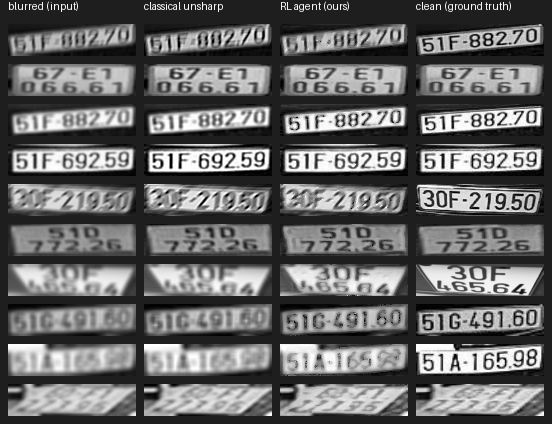

In [44]:
!python -m rl_deblur.make_samples --device cuda --num-samples 10 --dataset-dir outputs/rl_deblur/dataset --agent-checkpoint outputs/rl_deblur_ocr_reward/checkpoints/best_deblur_agent.pt --output outputs/rl_deblur_ocr_reward/samples/before_after_grid.png

from IPython.display import Image as IPImage, display
display(IPImage('outputs/rl_deblur_ocr_reward/samples/before_after_grid.png'))


## 8. Luu ket qua fine-tune ve Google Drive

Colab runtime la tam thoi (mat het khi ngat ket noi) -- nen `outputs/rl_deblur_ocr_reward/` de giu checkpoint, log, ket qua danh gia va anh minh hoa cua lan resume/fine-tune OCR-aware.


In [45]:
!zip -q -r outputs_rl_deblur_ocr_reward_result.zip outputs/rl_deblur_ocr_reward
!cp outputs_rl_deblur_ocr_reward_result.zip /content/drive/MyDrive/
print('Da luu outputs_rl_deblur_ocr_reward_result.zip vao Google Drive (My Drive).')


'zip' is not recognized as an internal or external command,
operable program or batch file.


Da luu outputs_rl_deblur_ocr_reward_result.zip vao Google Drive (My Drive).


'cp' is not recognized as an internal or external command,
operable program or batch file.
